# Stage 2 — DRS spectral shapes of difficult subjects
Generate the shared-scale 3 × 2 feature-source comparison for each prediction target, plus the anatomical-context figure.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from subject_nirs.stage2.subject_failure import (
    load_baseline_performance, load_layer_thickness_metadata, load_or_compute_signatures,
    make_subject_failure_feature_comparison_figure, make_failure_layer_thickness_figure,
)
BASELINE_DIRS = {
    'hc': Path('artifacts/stage2/baseline/hc'),
    'sto2': Path('artifacts/stage2/baseline/sto2'),
}
DTOF_DIRS = {
    'hc': Path('artifacts/stage2/residual/finetune/dtof/hc'),
    'sto2': Path('artifacts/stage2/residual/finetune/dtof/sto2'),
}
THICKNESS_DIRS = {
    'hc': Path('artifacts/stage2/residual/finetune/metadata/hc'),
    'sto2': Path('artifacts/stage2/residual/finetune/metadata/sto2'),
}
EXPECTED_SUBJECTS = 154
VALIDATION_CACHE = Path('cache/stage2/preprocessed_cache_grid_50k')
SIGNATURE_CACHE = Path('cache/stage2/subject_failure/subject_mean_signatures.npz')
METADATA_PATH = Path('data/temp_metadata_v2.csv')
FIGURE_DIR = Path('results/figures/stage2')
TABLE_DIR = Path('results/tables/stage2/subject_failure')

## 1. Build intensity-balanced subject signatures
For every subject, average the 30-channel relative-optical-density vectors within each tHb × StO₂ target cell and then equally across cells.

In [2]:
subject_ids, signatures = load_or_compute_signatures(
    SIGNATURE_CACHE,
    VALIDATION_CACHE / 'val_x_preprocessed.npy',
    VALIDATION_CACHE / 'val_y_all_targets.npy',
    VALIDATION_CACHE / 'val_subj_0based.npy',
    recompute=False,
)
subject_ids.shape, signatures.shape

((154,), (154, 30))

## 2. Generate feature-source and anatomical-context figures
Each model independently defines Q1/Q4 from its own held-out-subject RMSE and splits Q4 by its own signed Bias. The feature-source comparison uses the baseline Q1 median/MAD reference and one symmetric color scale across baseline, DTOF-descriptor, and tissue-thickness-feature rows. Thus color differences reflect changed difficult-group membership; neither subject feature changes the underlying DRS measurements. The anatomical-context figure separately fixes the DRS-only Q1/Q4 groups and reports raw scalp, skull, CSF, and frontal-sinus thickness differences in mm.

,target,target_display,figure,shared_color_limit,model,common_n,accurate_n,difficult_n,overestimation_n,underestimation_n,zero_bias_difficult_n,rmse_q25,rmse_q75,difficult_overlap_n,contrast_reference,overestimation_mean_abs_contrast,underestimation_mean_abs_contrast,overestimation_iqr_consistent_channels,underestimation_iqr_consistent_channels
0,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,drs_only,154,39,39,17,22,0,10.521772,17.889792,39,drs_only_q1_median_and_mad,0.772404,0.360207,20,4
1,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,residual_finetune_dtof,154,39,39,19,20,0,9.851041,17.161531,26,drs_only_q1_median_and_mad,0.673139,0.334521,13,5
2,hc,tHb,results/figures/stage2/subject_failure_feature...,1.833867,residual_finetune_thickness,154,39,39,17,22,0,9.925406,15.685256,26,drs_only_q1_median_and_mad,0.694198,0.382860,16,5
3,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,drs_only,154,39,39,22,17,0,0.035095,0.069571,39,drs_only_q1_median_and_mad,0.559221,0.901376,2,18
4,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,residual_finetune_dtof,154,39,39,23,16,0,0.033888,0.066441,33,drs_only_q1_median_and_mad,0.528557,0.882920,3,16
5,sto2,StO₂,results/figures/stage2/subject_failure_feature...,1.471108,residual_finetune_thickness,154,39,39,20,19,0,0.034796,0.064741,33,drs_only_q1_median_and_mad,0.491921,0.851011,2,14


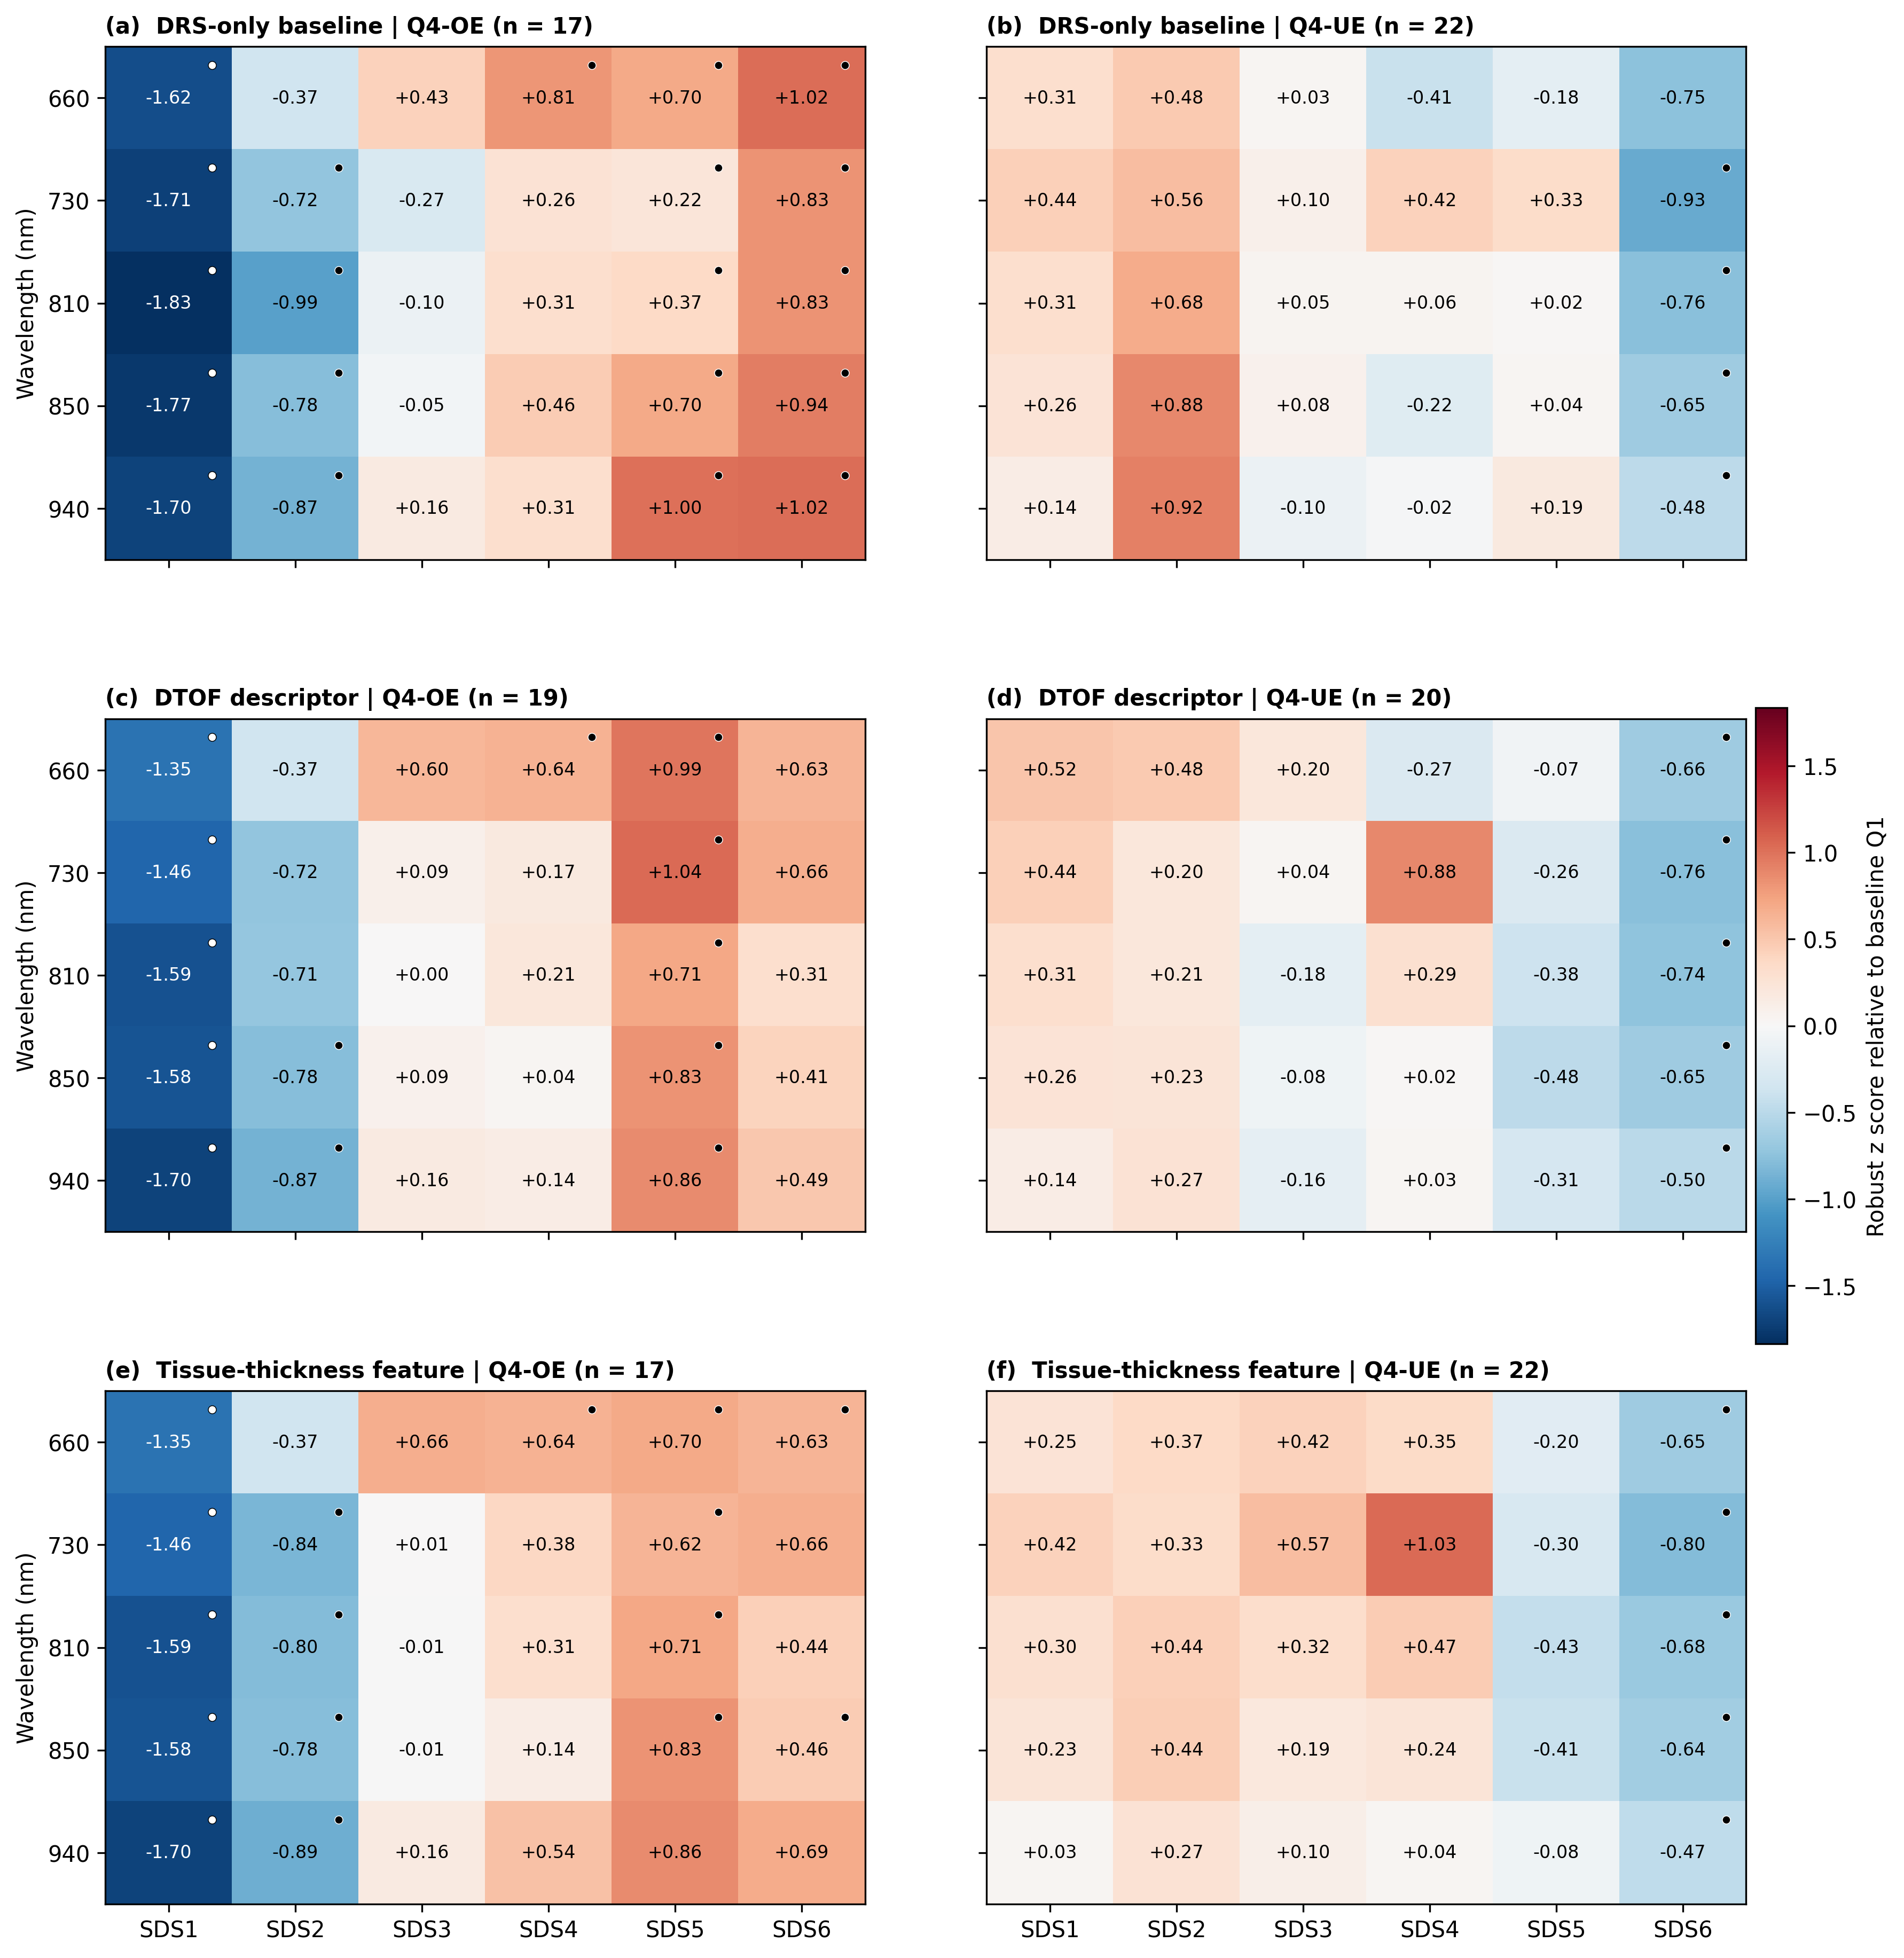

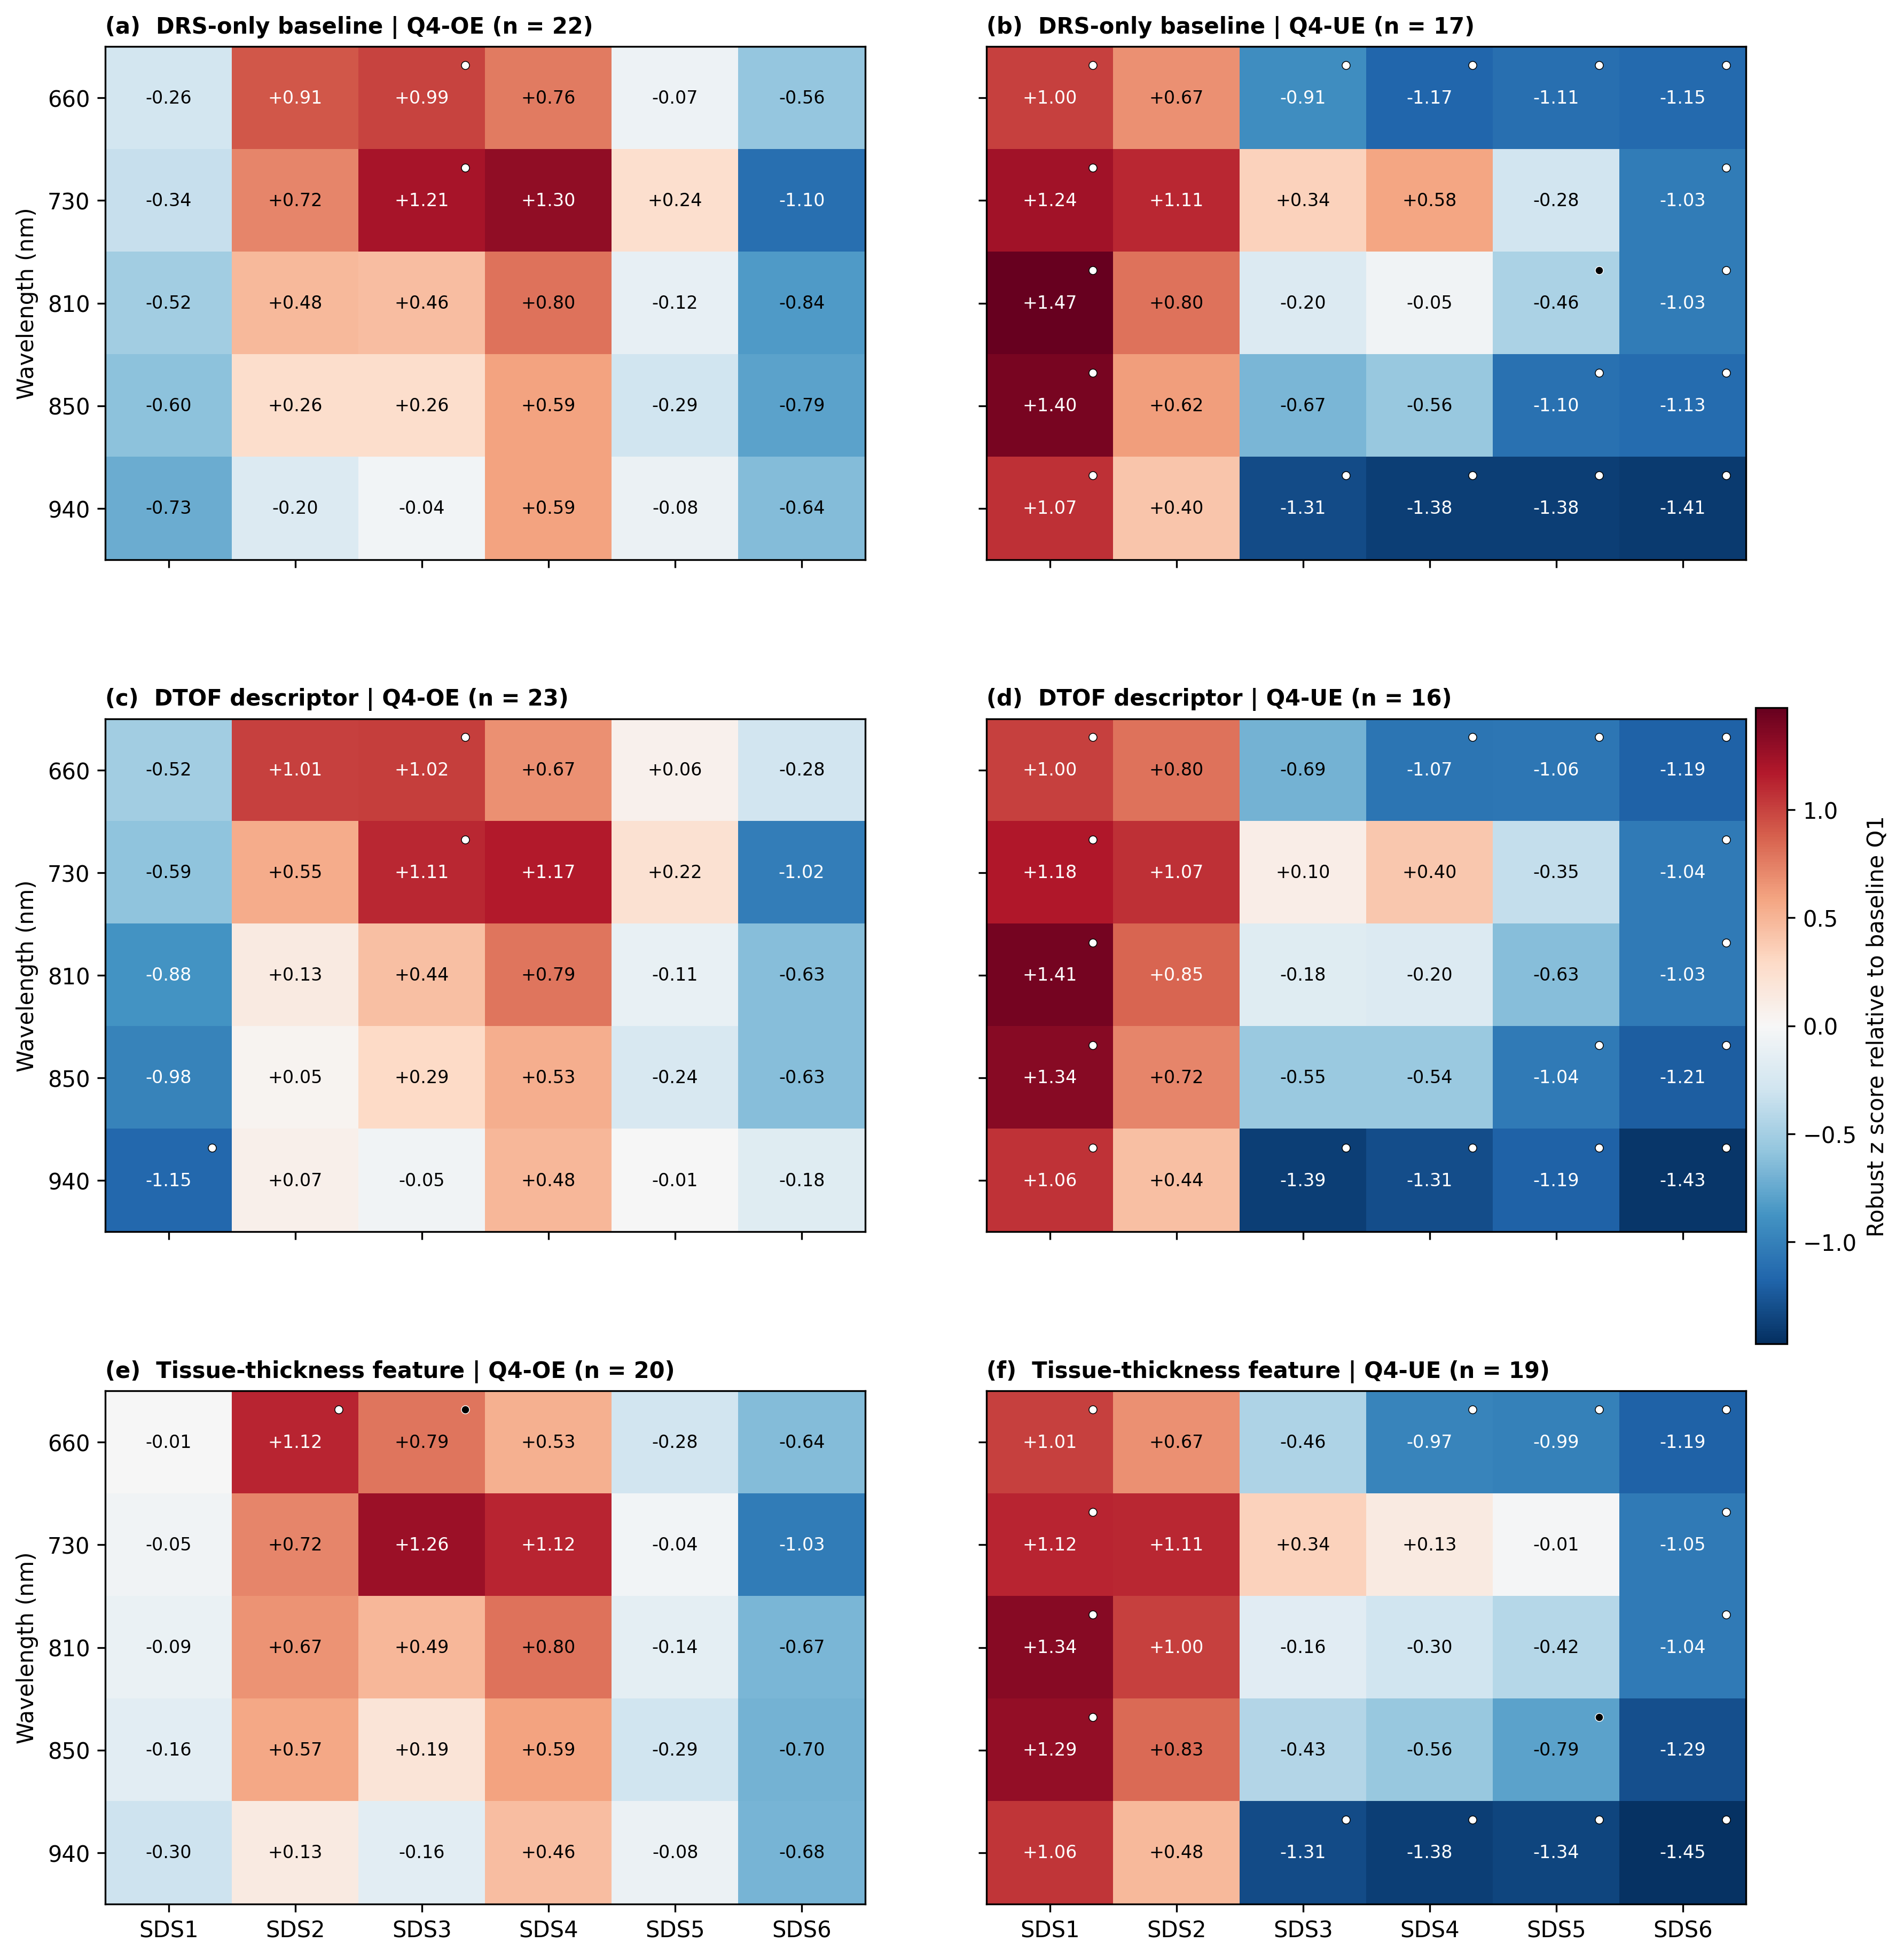

,target,target_display,group,layer,layer_display,common_n,reference_n,group_n,rmse_q25,rmse_q75,...,reference_q3_mm,group_median_mm,group_q1_mm,group_q3_mm,median_difference_mm,bootstrap_ci_low_mm,bootstrap_ci_high_mm,bootstrap_repeats,bootstrap_seed,figure
0,hc,tHb,overestimation,scalp,Scalp,154,39,17,10.521772,17.889792,...,3.83450,4.05380,3.834500,4.362100,0.57410,0.00000,1.140500,10000,20260917,results/figures/stage2/subject_failure_layer_t...
1,hc,tHb,overestimation,skull,Skull,154,39,17,10.521772,17.889792,...,6.44445,5.43040,4.697200,5.952100,0.44210,-0.68750,1.222100,10000,20260917,results/figures/stage2/subject_failure_layer_t...
2,hc,tHb,overestimation,csf,CSF,154,39,17,10.521772,17.889792,...,4.73505,3.23280,2.764300,3.959100,-0.82620,-1.59980,-0.099900,10000,20260917,results/figures/stage2/subject_failure_layer_t...
3,hc,tHb,overestimation,sinus,Frontal sinus,154,39,17,10.521772,17.889792,...,1.26680,0.67440,0.118600,1.620300,0.12260,-0.52930,1.027000,10000,20260917,results/figures/stage2/subject_failure_layer_t...
4,hc,tHb,underestimation,scalp,Scalp,154,39,22,10.521772,17.889792,...,3.83450,3.83450,2.962425,4.482525,0.35480,-0.35480,0.929250,10000,20260917,results/figures/stage2/subject_failure_layer_t...
5,hc,tHb,underestimation,skull,Skull,154,39,22,10.521772,17.889792,...,6.44445,5.49150,4.614450,6.398975,0.50320,-0.68440,1.532400,10000,20260917,results/figures/stage2/subject_failure_layer_t...
6,hc,tHb,underestimation,csf,CSF,154,39,22,10.521772,17.889792,...,4.73505,5.42290,4.577925,5.988425,1.36390,0.63710,1.912450,10000,20260917,results/figures/stage2/subject_failure_layer_t...
7,hc,tHb,underestimation,sinus,Frontal sinus,154,39,22,10.521772,17.889792,...,1.26680,1.65295,0.657000,4.040875,1.10115,0.14810,2.913050,10000,20260917,results/figures/stage2/subject_failure_layer_t...
8,sto2,StO₂,overestimation,scalp,Scalp,154,39,22,0.035095,0.069571,...,3.83450,4.74210,3.568400,5.635275,1.52050,0.56845,1.953700,10000,20260918,results/figures/stage2/subject_failure_layer_t...
9,sto2,StO₂,overestimation,skull,Skull,154,39,22,0.035095,0.069571,...,6.75625,5.79990,4.086900,7.373825,-0.06670,-1.67740,1.300000,10000,20260918,results/figures/stage2/subject_failure_layer_t...


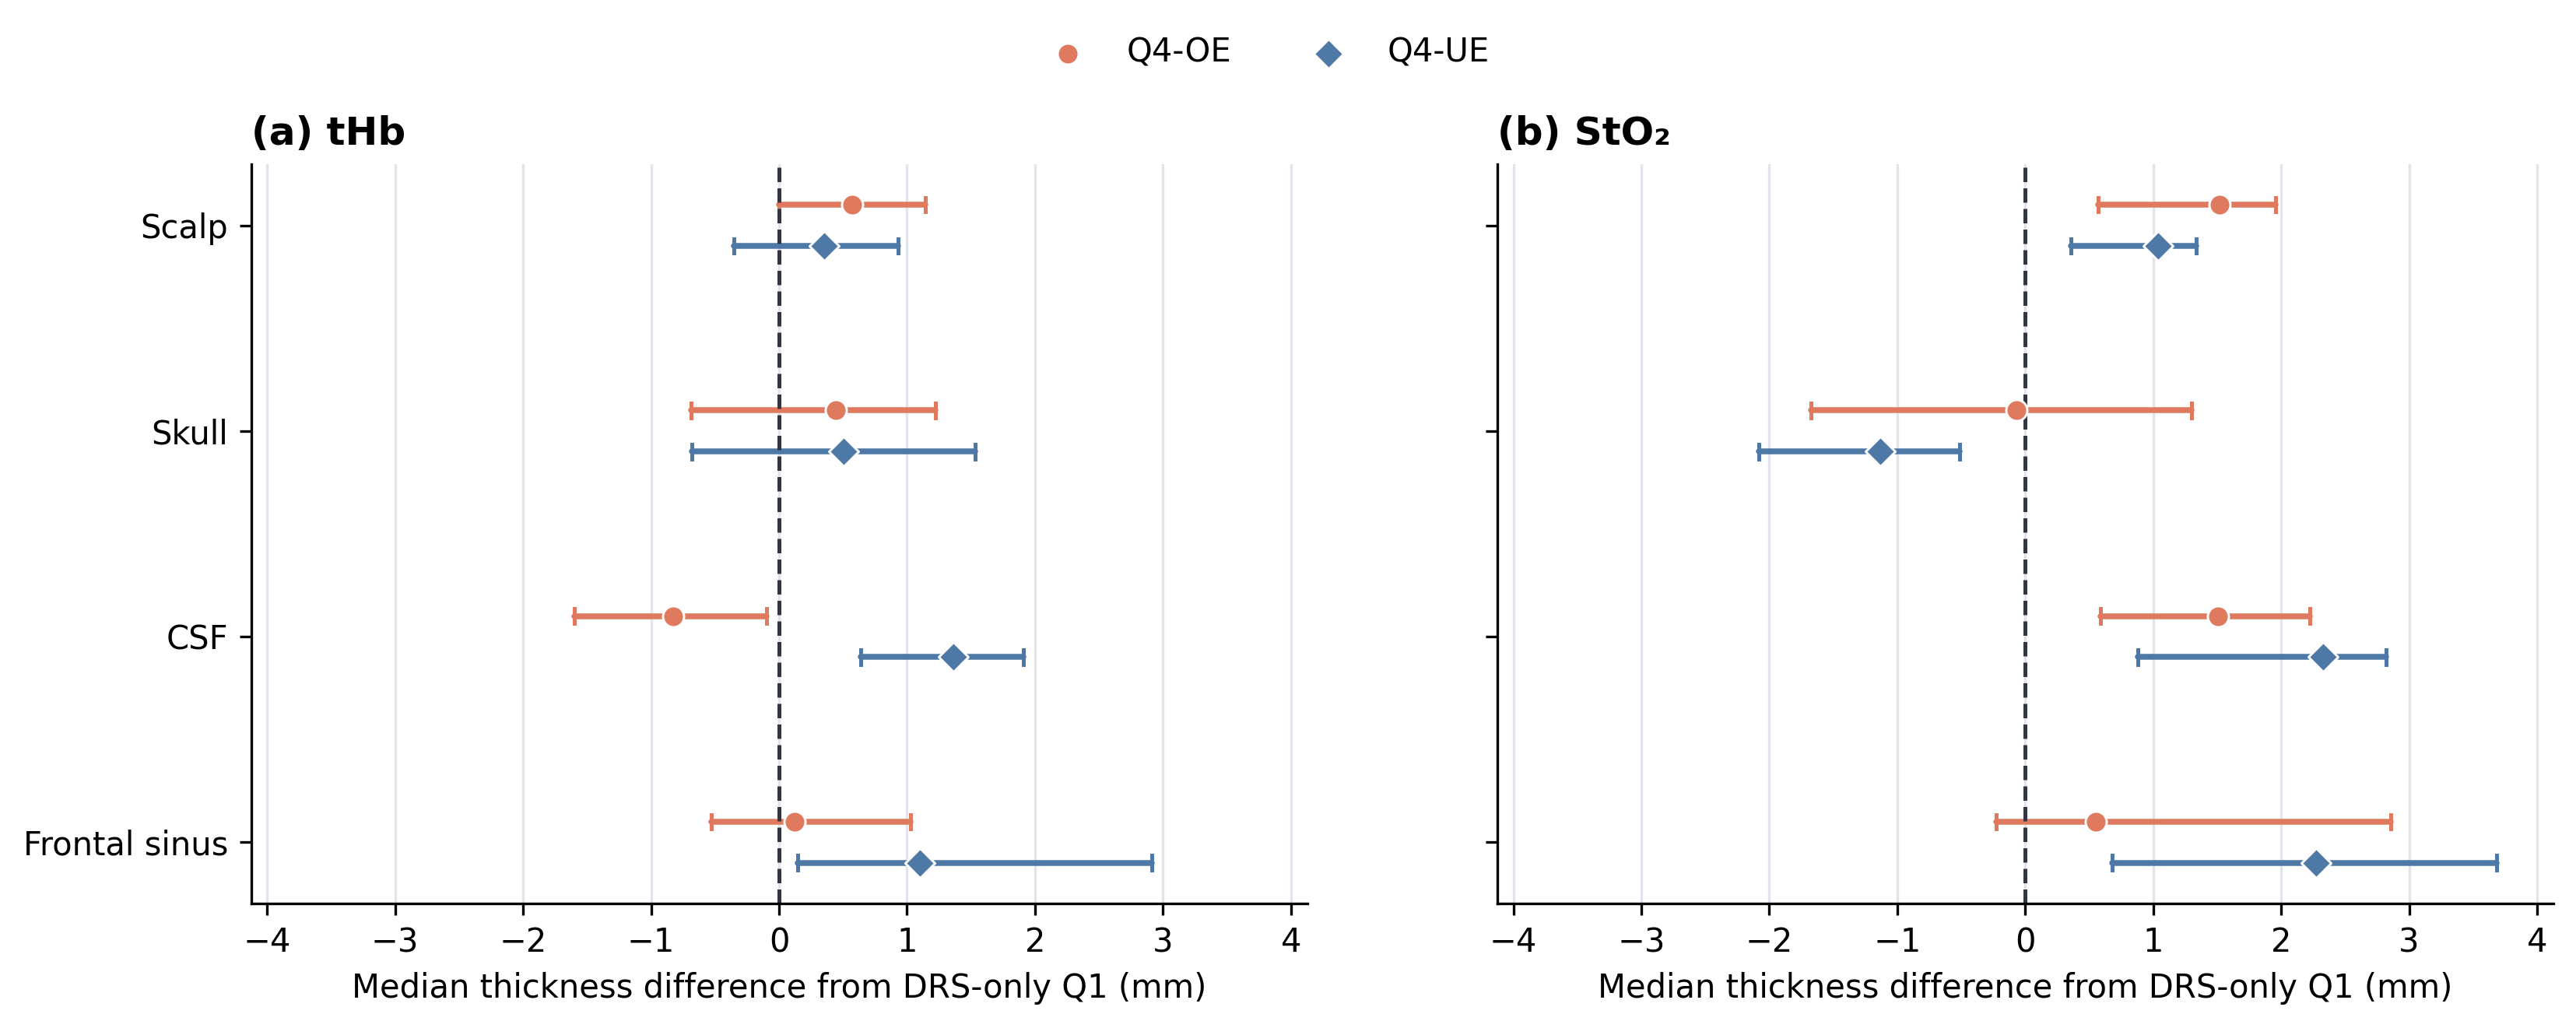

In [3]:
from IPython.display import Image, display

feature_comparison_summaries = []
baseline_performance = {}
for target_mode in BASELINE_DIRS:
    baseline = load_baseline_performance(BASELINE_DIRS[target_mode], target_mode)
    baseline_performance[target_mode] = baseline
    dtof = load_baseline_performance(DTOF_DIRS[target_mode], target_mode)
    thickness = load_baseline_performance(THICKNESS_DIRS[target_mode], target_mode)
    if any(len(frame) != EXPECTED_SUBJECTS for frame in (baseline, dtof, thickness)):
        raise ValueError(
            f'{target_mode}: expected {EXPECTED_SUBJECTS} subjects; '
            f'baseline={len(baseline)}, dtof={len(dtof)}, thickness={len(thickness)}'
        )
    feature_comparison_summaries.extend(
        make_subject_failure_feature_comparison_figure(
            baseline, dtof, thickness, subject_ids, signatures, FIGURE_DIR, target_mode
        )
    )

TABLE_DIR.mkdir(parents=True, exist_ok=True)
feature_comparison_table = pd.DataFrame(feature_comparison_summaries)
feature_comparison_table.to_csv(
    TABLE_DIR / 'subject_failure_feature_comparison_summary.csv', index=False
)
display(feature_comparison_table)
for target_mode in BASELINE_DIRS:
    display(Image(filename=str(FIGURE_DIR / f'subject_failure_feature_comparison_{target_mode}.png'), width=1300))

thickness_metadata = load_layer_thickness_metadata(METADATA_PATH)
if len(thickness_metadata) != EXPECTED_SUBJECTS:
    raise ValueError(
        f'Expected {EXPECTED_SUBJECTS} thickness records; found {len(thickness_metadata)}'
    )
thickness_context_table = make_failure_layer_thickness_figure(
    baseline_performance, thickness_metadata, FIGURE_DIR
)
thickness_context_table.to_csv(
    TABLE_DIR / 'subject_failure_layer_thickness_summary.csv', index=False
)
display(thickness_context_table)
display(Image(filename=str(FIGURE_DIR / 'subject_failure_layer_thickness.png'), width=1300))